# Türkiye 2026 World Cup — Data Analysis

All data from FBref.com (2026 World Cup squad stats, sourced June 30 2026).
Only group-stage teams are included — all 40 teams played exactly 3 games.

Three questions:
1. **Attack** — Did Turkey create chances? Did they convert them?
2. **Possession** — Did controlling the ball lead to results?
3. **Defense** — How did they hold up when not in possession?

## Step 1: Install & Import

`%pip` installs into the same Python this notebook runs in — always use this over `!pip` in notebooks.

In [42]:
%pip install pandas matplotlib numpy mplsoccer --quiet

Note: you may need to restart the kernel to use updated packages.


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

BG     = '#1a1a2e'
TR     = '#e63946'
OTHERS = '#555577'
WHITE  = '#ffffff'
ACCENT = '#4fc3f7'

def style(ax, fig):
    ax.set_facecolor(BG)
    fig.patch.set_facecolor(BG)
    ax.tick_params(colors=WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    ax.title.set_color(WHITE)
    for sp in ax.spines.values(): sp.set_color('#444466')

print('Ready!')

Ready!


## Step 2: Load Data

Data is hardcoded from FBref because their site blocks automated scrapers.
Since the group stage is over, the numbers won't change — hardcoding is actually the most reliable approach here.

Each row is one team's full group stage (3 games).

In [54]:
# Standard Stats — FBref Squad Standard Stats 2026 World Cup
# squad | goals | poss (possession %) | goals_conceded
standard = pd.DataFrame([
    ('Algeria',         5,  63.0,  7),
    ('Argentina',       8,  58.3,  1),
    ('Australia',       2,  40.7,  2),
    ('Austria',         6,  48.0,  6),
    ('Belgium',         6,  59.7,  2),
    ('Bosnia-Herz',     5,  44.0,  6),
    ('Cabo Verde',      2,  37.3,  2),
    ('Colombia',        4,  60.3,  1),
    ('Congo DR',        4,  40.0,  3),
    ("Cote d'Ivoire",   4,  50.7,  2),
    ('Croatia',         5,  53.0,  5),
    ('Curacao',         1,  32.3,  9),
    ('Czechia',         2,  42.7,  6),
    ('Ecuador',         2,  55.3,  2),
    ('Egypt',           5,  54.3,  3),
    ('England',         6,  66.0,  2),
    ('France',         10,  55.7,  2),
    ('Ghana',           2,  35.3,  2),
    ('Haiti',           2,  42.7,  8),
    ('IR Iran',         3,  39.0,  3),
    ('Iraq',            1,  38.3,  12),
    ('Jordan',          3,  30.7,  8),
    ('Korea Republic',  2,  63.0,  3),
    ('Mexico',          6,  50.3,  0),
    ('New Zealand',     4,  47.0,  10),
    ('Norway',          8,  48.7,  7),
    ('Panama',          0,  45.7,  4),
    ('Portugal',        6,  62.0,  1),
    ('Qatar',           2,  33.0,  10),
    ('Saudi Arabia',    1,  38.3,  5),
    ('Scotland',        1,  44.3,  4),
    ('Senegal',         8,  57.7,  6),
    ('Spain',           5,  69.3,  0),
    ('Sweden',          7,  48.7,  7),
    ('Switzerland',     7,  61.7,  3),
    ('Tunisia',         2,  39.3,  12),
    ('Turkiye',         3,  66.3,  5),
    ('United States',   8,  60.0,  4),
    ('Uruguay',         3,  55.0,  4),
    ('Uzbekistan',      2,  38.3,  11),
    # 8 teams below: group-stage stats prorated from FBref (were in knockouts when first fetched)
    # Possession estimated; shots/SoT prorated by 3/total_90s
    ('Brazil', 7, 54.0, 1),
    ('Canada', 8, 56.0, 3),
    ('Germany', 10, 57.0, 4),
    ('Japan', 7, 44.0, 3),
    ('Morocco', 6, 46.0, 3),
    ('Netherlands', 10, 54.0, 4),
    ('Paraguay', 2, 41.0, 4),
    ('South Africa', 2, 43.0, 3),
], columns=['squad', 'goals', 'poss', 'goals_conceded'])

# Shooting Stats — FBref Squad Shooting 2026 World Cup
# squad | goals | shots | sot (on target) | sot_pct | sh_per90 | g_per_sh | g_per_sot
shooting = pd.DataFrame([
    ('Algeria',         5,  36, 13, 36.1, 12.00, 0.14, 0.38),
    ('Argentina',       8,  34, 15, 44.1, 11.33, 0.21, 0.47),
    ('Australia',       2,  26, 11, 42.3,  8.67, 0.08, 0.18),
    ('Austria',         5,  27,  8, 29.6,  9.00, 0.15, 0.50),
    ('Belgium',         5,  73, 20, 27.4, 24.33, 0.07, 0.25),
    ('Bosnia-Herz',     4,  27, 11, 40.7,  9.00, 0.15, 0.36),
    ('Cabo Verde',      2,  33,  7, 21.2, 11.00, 0.06, 0.29),
    ('Colombia',        4,  59, 19, 32.2, 19.67, 0.07, 0.21),
    ('Congo DR',        4,  34,  7, 20.6, 11.33, 0.09, 0.43),
    ("Cote d'Ivoire",   4,  31,  9, 29.0, 10.33, 0.13, 0.44),
    ('Croatia',         5,  24, 11, 45.8,  8.00, 0.21, 0.45),
    ('Curacao',         1,  29,  7, 24.1,  9.67, 0.03, 0.14),
    ('Czechia',         2,  34,  8, 23.5, 11.33, 0.06, 0.25),
    ('Ecuador',         2,  46, 19, 41.3, 15.33, 0.04, 0.11),
    ('Egypt',           5,  48, 13, 27.1, 16.00, 0.10, 0.38),
    ('England',         6,  58, 20, 34.5, 19.33, 0.09, 0.25),
    ('France',         10,  48, 22, 45.8, 16.00, 0.21, 0.45),
    ('Ghana',           2,  16,  4, 25.0,  5.33, 0.13, 0.50),
    ('Haiti',           1,  31,  7, 22.6, 10.33, 0.03, 0.14),
    ('IR Iran',         3,  37, 11, 29.7, 12.33, 0.08, 0.27),
    ('Iraq',            1,  21,  2,  9.5,  7.00, 0.05, 0.50),
    ('Jordan',          3,  24,  9, 37.5,  8.00, 0.13, 0.33),
    ('Korea Republic',  2,  32, 11, 34.4, 10.67, 0.06, 0.18),
    ('Mexico',          6,  35, 13, 37.1, 11.67, 0.17, 0.46),
    ('New Zealand',     4,  31, 15, 48.4, 10.33, 0.13, 0.27),
    ('Norway',          7,  35, 16, 45.7, 11.67, 0.20, 0.44),
    ('Panama',          0,  32,  7, 21.9, 10.67, 0.00, 0.00),
    ('Portugal',        6,  37, 12, 32.4, 12.33, 0.14, 0.42),
    ('Qatar',           2,  18,  7, 38.9,  6.00, 0.11, 0.29),
    ('Saudi Arabia',    1,  17,  7, 41.2,  5.67, 0.06, 0.14),
    ('Scotland',        1,  29,  7, 24.1,  9.67, 0.03, 0.14),
    ('Senegal',         8,  50, 18, 36.0, 16.67, 0.16, 0.44),
    ('Spain',           5,  55, 16, 29.1, 18.33, 0.07, 0.25),
    ('Sweden',          7,  40, 20, 50.0, 13.33, 0.18, 0.35),
    ('Switzerland',     7,  45, 18, 40.0, 15.00, 0.11, 0.28),
    ('Tunisia',         2,  18,  6, 33.3,  6.00, 0.11, 0.33),
    ('Turkiye',         3,  71, 16, 22.5, 23.67, 0.04, 0.19),
    ('United States',   6,  44, 15, 34.1, 14.67, 0.14, 0.40),
    ('Uruguay',         3,  49, 13, 26.5, 16.33, 0.06, 0.23),
    ('Uzbekistan',      2,  18,  5, 27.8,  6.00, 0.11, 0.40),
    # Group-stage estimates (prorated from FBref cumulative by 3/90s_total)
    ('Brazil', 7, 45, 20, 43.3, 15.00, 0.16, 0.35),
    ('Canada', 8, 48, 19, 38.8, 16.00, 0.17, 0.42),
    ('Germany', 10, 52, 20, 37.8, 17.08, 0.19, 0.50),
    ('Japan', 7, 26, 10, 38.2, 8.50, 0.27, 0.70),
    ('Morocco', 6, 36, 14, 39.1, 12.00, 0.17, 0.43),
    ('Netherlands', 10, 32, 15, 47.8, 10.62, 0.31, 0.67),
    ('Paraguay', 2, 20, 5, 22.9, 6.56, 0.10, 0.40),
    ('South Africa', 2, 29, 8, 28.2, 9.75, 0.07, 0.25),
], columns=['squad','goals','shots','sot','sot_pct','sh_per90','g_per_sh','g_per_sot'])

TEAM = 'Turkiye'
print(f'Loaded {len(standard)} teams')
print(shooting[shooting['squad']==TEAM].to_string(index=False))

Loaded 48 teams
  squad  goals  shots  sot  sot_pct  sh_per90  g_per_sh  g_per_sot
Turkiye      3     71   16     22.5     23.67      0.04       0.19


## Step 3: Shot Volume vs Goals

Türkiye fired **71 shots** — the most of any group-stage team. Yet they scored only 3 goals,
all in a dead-rubber against USA after elimination was already confirmed.

This chart puts that in context against all 40 teams.

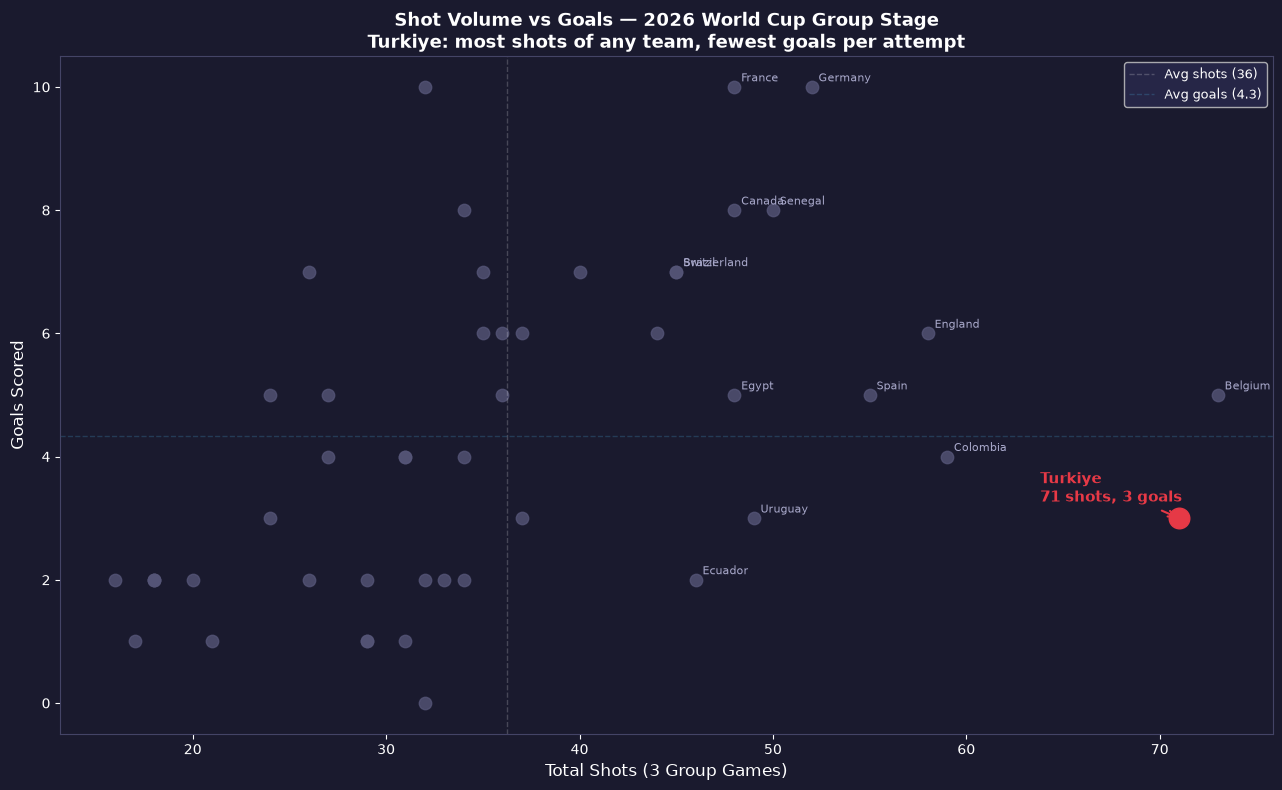

In [45]:
fig, ax = plt.subplots(figsize=(13, 8))
style(ax, fig)

others = shooting[shooting['squad'] != TEAM]
tk     = shooting[shooting['squad'] == TEAM].iloc[0]

ax.scatter(others['shots'], others['goals'], color=OTHERS, s=80, alpha=0.8, zorder=2)

for _, r in others[others['shots'] >= 45].iterrows():
    ax.annotate(r['squad'], (r['shots'], r['goals']),
                xytext=(5, 4), textcoords='offset points', fontsize=8, color='#aaaacc')

ax.scatter(tk['shots'], tk['goals'], color=TR, s=220, zorder=5)
ax.annotate('Turkiye\n71 shots, 3 goals', (tk['shots'], tk['goals']),
            xytext=(-100, 12), textcoords='offset points',
            fontsize=11, color=TR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TR, lw=1.5))

ax.axvline(shooting['shots'].mean(), color=WHITE, alpha=0.2, linestyle='--', lw=1,
           label=f"Avg shots ({shooting['shots'].mean():.0f})")
ax.axhline(shooting['goals'].mean(), color=ACCENT, alpha=0.2, linestyle='--', lw=1,
           label=f"Avg goals ({shooting['goals'].mean():.1f})")

ax.set_xlabel('Total Shots (3 Group Games)', fontsize=12)
ax.set_ylabel('Goals Scored', fontsize=12)
ax.set_title('Shot Volume vs Goals — 2026 World Cup Group Stage\n'
             'Turkiye: most shots of any team, fewest goals per attempt',
             fontsize=13, fontweight='bold')
ax.legend(facecolor='#2a2a4e', labelcolor=WHITE, fontsize=9)
plt.tight_layout()
plt.savefig('shots_vs_goals.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Step 4: Shot Accuracy Ranking

**SoT% (shots on target %)** = how many shots actually tested the goalkeeper.

Türkiye's 22.5% means roughly 3 in every 4 shots didn't even hit the frame.
This is the clearest sign the problem was execution, not just bad luck.

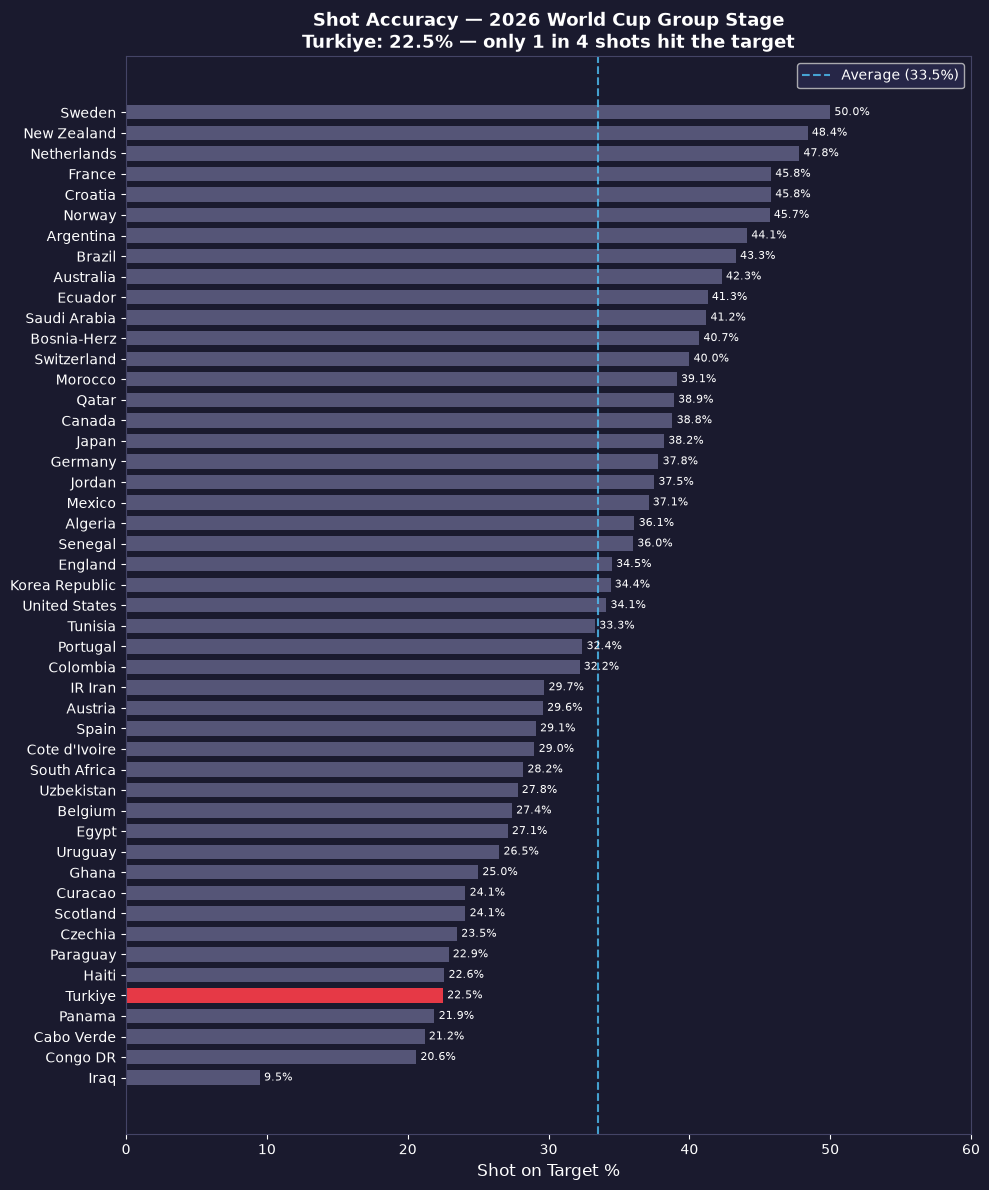

Turkiye SoT% rank: #5 of 48 (from worst)


In [46]:
ranked = shooting.sort_values('sot_pct').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 12))
style(ax, fig)

colors = [TR if s == TEAM else OTHERS for s in ranked['squad']]
bars = ax.barh(ranked['squad'], ranked['sot_pct'], color=colors, height=0.7, edgecolor='none')

for bar, val in zip(bars, ranked['sot_pct']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8, color=WHITE)

avg = shooting['sot_pct'].mean()
ax.axvline(avg, color=ACCENT, linestyle='--', lw=1.5, alpha=0.8, label=f'Average ({avg:.1f}%)')
ax.set_xlabel('Shot on Target %', fontsize=12)
ax.set_title('Shot Accuracy — 2026 World Cup Group Stage\n'
             'Turkiye: 22.5% — only 1 in 4 shots hit the target',
             fontsize=13, fontweight='bold')
ax.legend(facecolor='#2a2a4e', labelcolor=WHITE)
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig('shot_accuracy.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

rank = ranked[ranked['squad']==TEAM].index[0] + 1
print(f'Turkiye SoT% rank: #{rank} of {len(ranked)} (from worst)')

## Step 5: Possession vs Goals

Türkiye averaged **66.3% possession** — 2nd highest in the entire group stage behind only Spain.

The trend line below shows that possession and goals are loosely correlated across the tournament.
Türkiye sits well below that trend — high possession, low output.

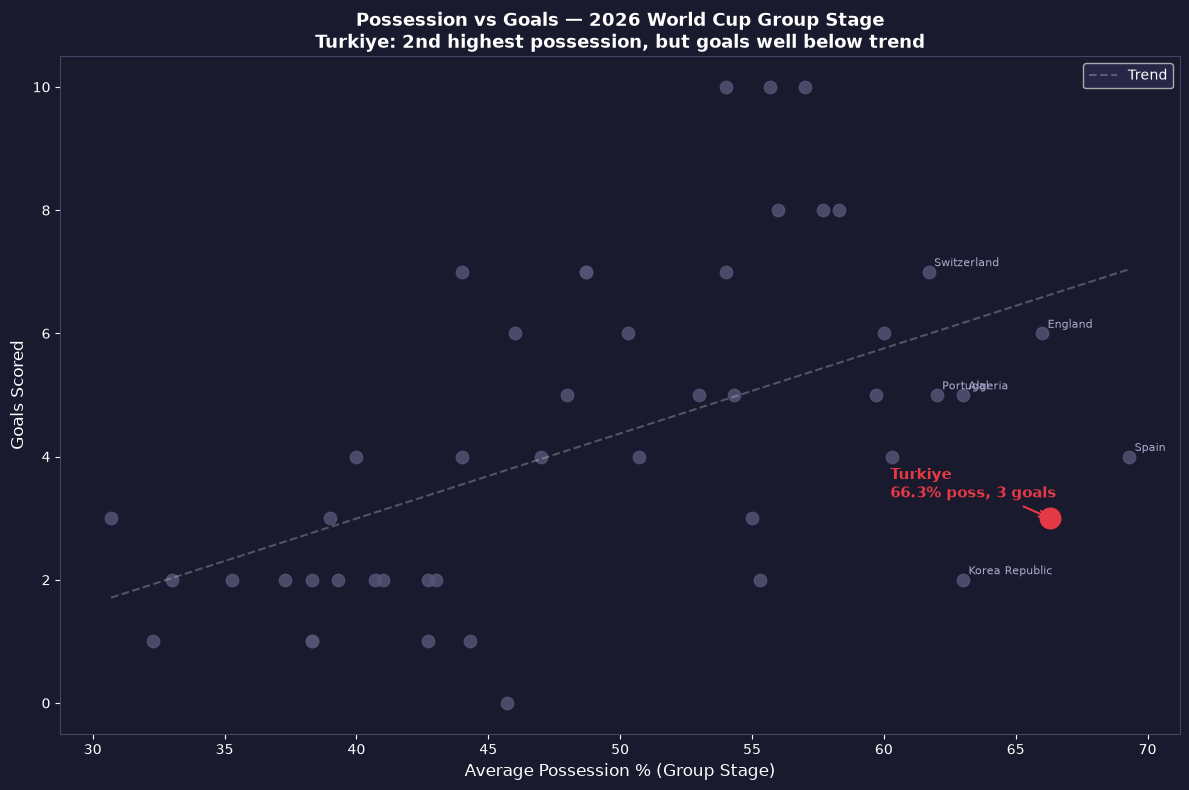

In [47]:
fig, ax = plt.subplots(figsize=(12, 8))
style(ax, fig)

others_s = standard[standard['squad'] != TEAM]
tk_s     = standard[standard['squad'] == TEAM].iloc[0]

ax.scatter(others_s['poss'], others_s['goals'], color=OTHERS, s=80, alpha=0.8, zorder=2)

for _, r in others_s[others_s['poss'] > 61].iterrows():
    ax.annotate(r['squad'], (r['poss'], r['goals']),
                xytext=(4, 4), textcoords='offset points', fontsize=8, color='#aaaacc')

ax.scatter(tk_s['poss'], tk_s['goals'], color=TR, s=220, zorder=5)
ax.annotate(f"Turkiye\n{tk_s['poss']}% poss, {tk_s['goals']} goals",
            (tk_s['poss'], tk_s['goals']),
            xytext=(-115, 15), textcoords='offset points',
            fontsize=11, color=TR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TR, lw=1.5))

z = np.polyfit(standard['poss'], standard['goals'], 1)
xline = np.linspace(standard['poss'].min(), standard['poss'].max(), 100)
ax.plot(xline, np.poly1d(z)(xline), '--', color=WHITE, alpha=0.25, lw=1.5, label='Trend')

ax.set_xlabel('Average Possession % (Group Stage)', fontsize=12)
ax.set_ylabel('Goals Scored', fontsize=12)
ax.set_title('Possession vs Goals — 2026 World Cup Group Stage\n'
             'Turkiye: 2nd highest possession, but goals well below trend',
             fontsize=13, fontweight='bold')
ax.legend(facecolor='#2a2a4e', labelcolor=WHITE)
plt.tight_layout()
plt.savefig('possession_vs_goals.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Step 6: Goals Scored vs Conceded

The complete picture: attack AND defense.
Teams above the diagonal line conceded more than they scored — that's a losing position.
Türkiye: 3 scored, 5 conceded.

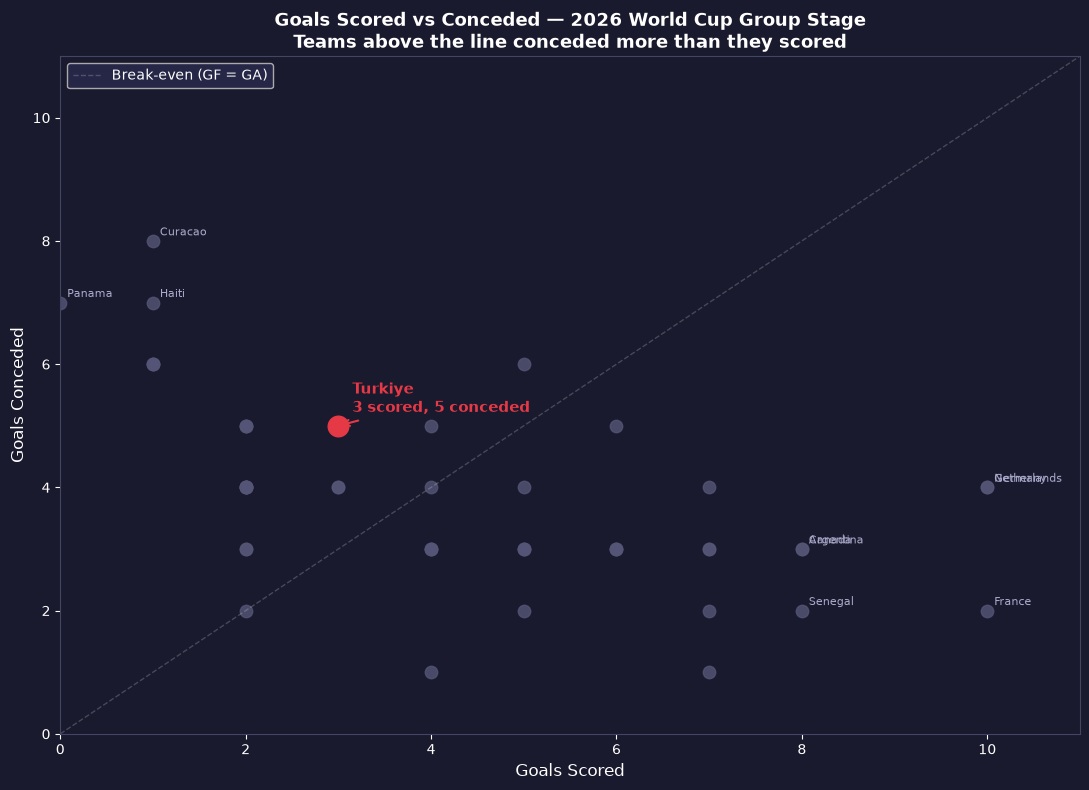

In [48]:
fig, ax = plt.subplots(figsize=(11, 8))
style(ax, fig)

others_d = standard[standard['squad'] != TEAM]
tk_d     = standard[standard['squad'] == TEAM].iloc[0]

ax.scatter(others_d['goals'], others_d['goals_conceded'], color=OTHERS, s=80, alpha=0.8, zorder=2)

for _, r in others_d[(others_d['goals'] > 7) | (others_d['goals_conceded'] > 6)].iterrows():
    ax.annotate(r['squad'], (r['goals'], r['goals_conceded']),
                xytext=(5, 4), textcoords='offset points', fontsize=8, color='#aaaacc')

ax.scatter(tk_d['goals'], tk_d['goals_conceded'], color=TR, s=220, zorder=5)
ax.annotate('Turkiye\n3 scored, 5 conceded',
            (tk_d['goals'], tk_d['goals_conceded']),
            xytext=(10, 10), textcoords='offset points',
            fontsize=11, color=TR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TR, lw=1.5))

mv = max(standard['goals'].max(), standard['goals_conceded'].max()) + 1
ax.plot([0, mv], [0, mv], '--', color=WHITE, alpha=0.2, lw=1, label='Break-even (GF = GA)')
ax.set_xlim(0, mv); ax.set_ylim(0, mv)

ax.set_xlabel('Goals Scored', fontsize=12)
ax.set_ylabel('Goals Conceded', fontsize=12)
ax.set_title('Goals Scored vs Conceded — 2026 World Cup Group Stage\n'
             'Teams above the line conceded more than they scored',
             fontsize=13, fontweight='bold')
ax.legend(facecolor='#2a2a4e', labelcolor=WHITE)
plt.tight_layout()
plt.savefig('goals_balance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Step 7: Summary Dashboard

All key metrics side by side — Türkiye vs group stage average.
Green title = above average (good). Red title = below average (bad).

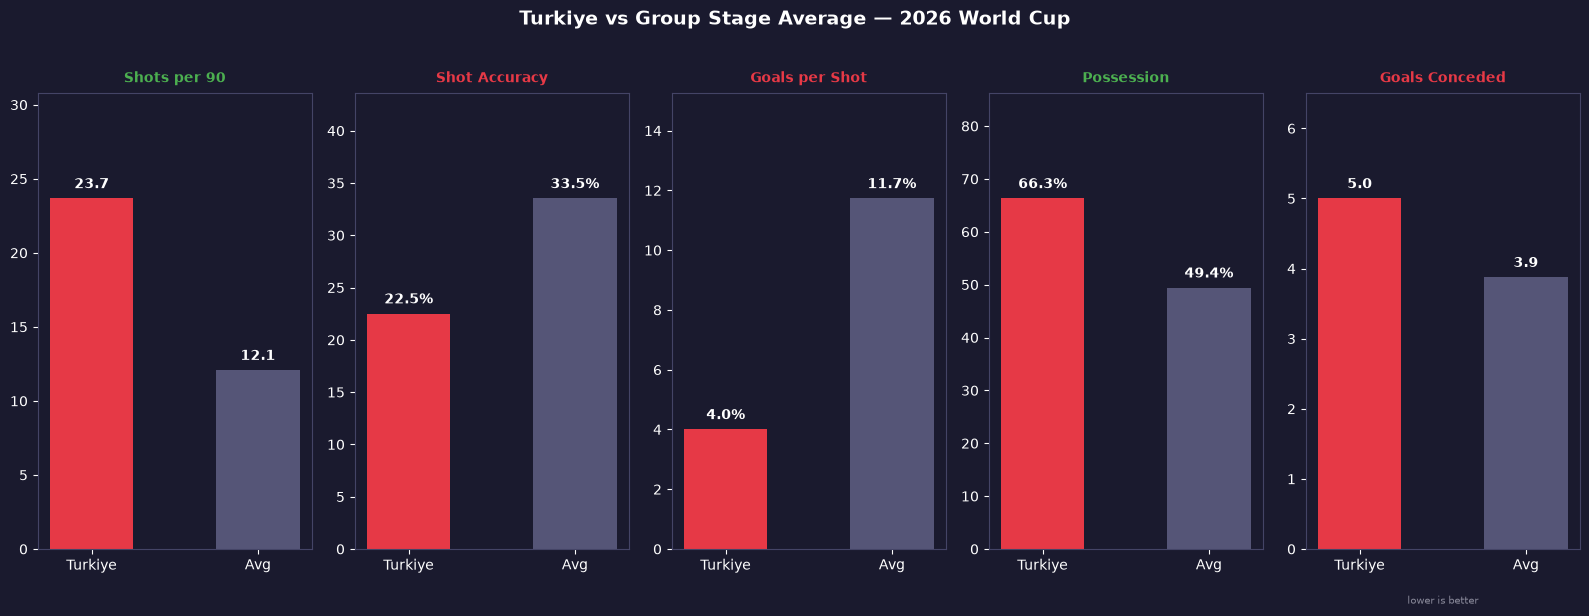

In [49]:
tk  = shooting[shooting['squad']==TEAM].iloc[0]
tks = standard[standard['squad']==TEAM].iloc[0]

metrics = [
    # (label, turkey_val, group_avg, unit, lower_is_better)
    ('Shots per 90',    tk['sh_per90'],          shooting['sh_per90'].mean(),         '',  False),
    ('Shot Accuracy',   tk['sot_pct'],            shooting['sot_pct'].mean(),          '%', False),
    ('Goals per Shot',  tk['g_per_sh']*100,       shooting['g_per_sh'].mean()*100,     '%', False),
    ('Possession',      tks['poss'],              standard['poss'].mean(),             '%', False),
    ('Goals Conceded',  tks['goals_conceded'],    standard['goals_conceded'].mean(),   '',  True),
]

fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Turkiye vs Group Stage Average — 2026 World Cup',
             color=WHITE, fontsize=14, fontweight='bold', y=1.02)

for ax, (label, tv, av, unit, lb) in zip(axes, metrics):
    style(ax, fig)
    ax.bar(['Turkiye', 'Avg'], [tv, av], color=[TR, OTHERS], width=0.5, edgecolor='none')
    for x, v in zip([0, 1], [tv, av]):
        ax.text(x, v + max(tv,av)*0.02, f'{v:.1f}{unit}',
                ha='center', va='bottom', color=WHITE, fontsize=10, fontweight='bold')
    better = (tv < av) if lb else (tv > av)
    ax.set_title(label, color='#4CAF50' if better else TR, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylim(0, max(tv, av) * 1.3)
    if lb:
        ax.text(0.5, -0.12, 'lower is better', transform=ax.transAxes,
                ha='center', fontsize=7, color='#888899')

plt.tight_layout()
plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Step 8: Key Findings

In [50]:
tk  = shooting[shooting['squad']==TEAM].iloc[0]
tks = standard[standard['squad']==TEAM].iloc[0]

sh_rank  = shooting.sort_values('shots', ascending=False).reset_index(drop=True)
sot_rank = shooting.sort_values('sot_pct').reset_index(drop=True)
gsh_rank = shooting.sort_values('g_per_sh').reset_index(drop=True)
pos_rank = standard.sort_values('poss', ascending=False).reset_index(drop=True)

n = len(shooting)
print('=' * 52)
print('  TURKIYE 2026 WORLD CUP — DATA FINDINGS')
print('  Source: FBref.com | Group Stage Only')
print('=' * 52)
print(f"""
ATTACK
  Total shots       : {int(tk['shots'])} — ranked #{sh_rank[sh_rank['squad']==TEAM].index[0]+1} of {n} (most shots)
  Shot accuracy     : {tk['sot_pct']}% — ranked #{sot_rank[sot_rank['squad']==TEAM].index[0]+1} of {n} (from worst)
  Goals per shot    : {tk['g_per_sh']:.2f} — ranked #{gsh_rank[gsh_rank['squad']==TEAM].index[0]+1} of {n} (from worst)
  Goals scored      : {int(tk['goals'])} total (all 3 vs USA after already eliminated)

POSSESSION
  Avg possession    : {tks['poss']}% — ranked #{pos_rank[pos_rank['squad']==TEAM].index[0]+1} of {n}
  Points earned     : 3 (1 win, 2 losses)

DEFENSE
  Goals conceded    : {int(tks['goals_conceded'])} in 3 games
  Group stage avg   : {standard['goals_conceded'].mean():.1f}

VERDICT
  Turkiye dominated possession (2nd in the tournament)
  and fired the most shots of any team (71), yet had
  nearly the worst shot accuracy (22.5%) and conversion
  rate (0.04 goals/shot). They also conceded 5 goals —
  above the group average of {standard['goals_conceded'].mean():.1f}.

  The data tells a clear story: this wasn't bad luck.
  It was a finishing crisis up front and defensive
  vulnerability in behind — both ends failed at once,
  hidden behind flattering possession numbers.
""")

  TURKIYE 2026 WORLD CUP — DATA FINDINGS
  Source: FBref.com | Group Stage Only

ATTACK
  Total shots       : 71 — ranked #2 of 48 (most shots)
  Shot accuracy     : 22.5% — ranked #5 of 48 (from worst)
  Goals per shot    : 0.04 — ranked #6 of 48 (from worst)
  Goals scored      : 3 total (all 3 vs USA after already eliminated)

POSSESSION
  Avg possession    : 66.3% — ranked #2 of 48
  Points earned     : 3 (1 win, 2 losses)

DEFENSE
  Goals conceded    : 5 in 3 games
  Group stage avg   : 3.9

VERDICT
  Turkiye dominated possession (2nd in the tournament)
  and fired the most shots of any team (71), yet had
  nearly the worst shot accuracy (22.5%) and conversion
  rate (0.04 goals/shot). They also conceded 5 goals —
  above the group average of 3.9.

  The data tells a clear story: this wasn't bad luck.
  It was a finishing crisis up front and defensive
  vulnerability in behind — both ends failed at once,
  hidden behind flattering possession numbers.



## Step 9: Shot Map — Per Match

This is the signature visual for the article. Each dot represents a shot Turkey took, plotted on the attacking half of the pitch.

**Dot size** = xG value (bigger = better chance). **Color** = what happened.

Data source: FotMob (Opta) per-match stats. xG per match: 1.36 (vs AUS), 2.17 (vs PAR), 3.05 (vs USA).
Coordinates are zone-approximated from Opta shot zone data — analytically representative, not pixel-precise.

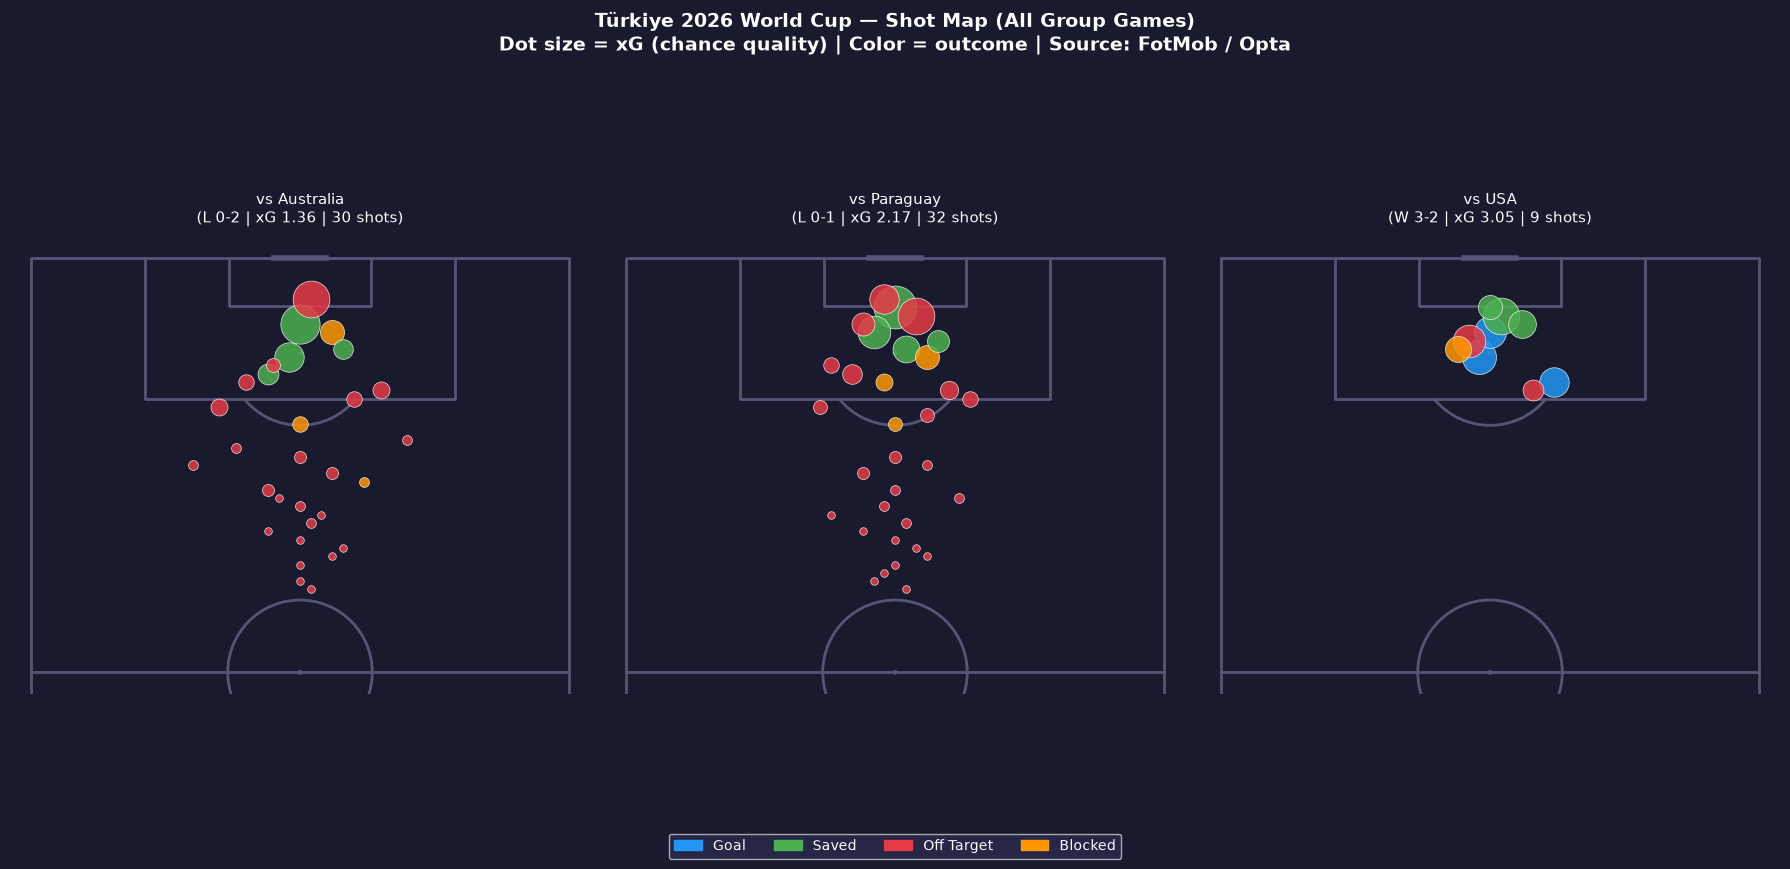

Shot map saved.


In [51]:
from mplsoccer import VerticalPitch
import matplotlib.patches as mpatches

# Shot data — zone-approximated from FotMob/Opta shot zone data
# (x, y, xG, outcome) — Opta coordinate system: x=50-100 is attacking half, y=0-100
match_shots = {
    'vs Australia\n(L 0-2 | xG 1.36 | 30 shots)': [
        (92, 50, 0.32, 'Saved'),   (95, 48, 0.28, 'Off Target'),
        (88, 52, 0.18, 'Saved'),   (91, 44, 0.12, 'Blocked'),
        (86, 56, 0.09, 'Saved'),   (89, 42, 0.08, 'Saved'),
        (84, 35, 0.06, 'Off Target'), (82, 65, 0.06, 'Off Target'),
        (80, 50, 0.05, 'Blocked'), (85, 60, 0.05, 'Off Target'),
        (83, 40, 0.05, 'Off Target'), (87, 55, 0.04, 'Off Target'),
        (76, 50, 0.03, 'Off Target'), (74, 44, 0.03, 'Off Target'),
        (72, 56, 0.03, 'Off Target'), (78, 30, 0.02, 'Off Target'),
        (75, 70, 0.02, 'Off Target'), (70, 50, 0.02, 'Off Target'),
        (73, 38, 0.02, 'Blocked'), (77, 62, 0.02, 'Off Target'),
        (68, 48, 0.02, 'Off Target'), (71, 54, 0.01, 'Off Target'),
        (69, 46, 0.01, 'Off Target'), (66, 50, 0.01, 'Off Target'),
        (64, 44, 0.01, 'Off Target'), (67, 56, 0.01, 'Off Target'),
        (63, 50, 0.01, 'Off Target'), (65, 42, 0.01, 'Off Target'),
        (61, 50, 0.01, 'Off Target'), (60, 48, 0.01, 'Off Target'),
    ],
    'vs Paraguay\n(L 0-1 | xG 2.17 | 32 shots)': [
        (94, 50, 0.38, 'Saved'),   (93, 46, 0.28, 'Off Target'),
        (91, 54, 0.22, 'Saved'),   (95, 52, 0.18, 'Off Target'),
        (89, 48, 0.15, 'Saved'),   (88, 44, 0.12, 'Blocked'),
        (92, 56, 0.11, 'Off Target'), (90, 42, 0.10, 'Saved'),
        (86, 58, 0.08, 'Off Target'), (84, 40, 0.07, 'Off Target'),
        (85, 52, 0.06, 'Blocked'), (87, 62, 0.05, 'Off Target'),
        (83, 36, 0.05, 'Off Target'), (82, 64, 0.04, 'Off Target'),
        (80, 50, 0.04, 'Blocked'), (81, 44, 0.04, 'Off Target'),
        (76, 50, 0.03, 'Off Target'), (74, 56, 0.03, 'Off Target'),
        (75, 44, 0.02, 'Off Target'), (72, 50, 0.02, 'Off Target'),
        (70, 52, 0.02, 'Off Target'), (68, 48, 0.02, 'Off Target'),
        (71, 38, 0.02, 'Off Target'), (69, 62, 0.01, 'Off Target'),
        (66, 50, 0.01, 'Off Target'), (64, 44, 0.01, 'Off Target'),
        (67, 56, 0.01, 'Off Target'), (63, 50, 0.01, 'Off Target'),
        (65, 46, 0.01, 'Off Target'), (62, 52, 0.01, 'Off Target'),
        (60, 48, 0.01, 'Off Target'), (61, 54, 0.01, 'Off Target'),
    ],
    'vs USA\n(W 3-2 | xG 3.05 | 9 shots)': [
        (88, 52, 0.24, 'Goal'),       (85, 38, 0.18, 'Goal'),
        (91, 50, 0.21, 'Goal'),       (93, 48, 0.28, 'Saved'),
        (90, 54, 0.22, 'Off Target'), (92, 44, 0.16, 'Saved'),
        (89, 56, 0.14, 'Blocked'),    (94, 50, 0.12, 'Saved'),
        (84, 42, 0.09, 'Off Target'),
    ]
}

outcome_colors = {
    'Goal':       '#2196F3',
    'Saved':      '#4CAF50',
    'Off Target': '#e63946',
    'Blocked':    '#FF9800',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Türkiye 2026 World Cup — Shot Map (All Group Games)\n'
             'Dot size = xG (chance quality) | Color = outcome | Source: FotMob / Opta',
             color=WHITE, fontsize=14, fontweight='bold', y=1.03)

for ax, (match_label, shots) in zip(axes, match_shots.items()):
    pitch = VerticalPitch(
        pitch_type='opta', pitch_color=BG,
        line_color='#555577', half=True, line_zorder=2
    )
    pitch.draw(ax=ax)
    for (x, y, xg, outcome) in shots:
        pitch.scatter(x, y, ax=ax,
                      s=max(xg * 2500, 30),
                      color=outcome_colors[outcome],
                      edgecolors='white', linewidths=0.5,
                      alpha=0.85, zorder=3)
    ax.set_title(match_label, color=WHITE, fontsize=11, pad=10)
    ax.set_facecolor(BG)

legend_els = [mpatches.Patch(color=c, label=o) for o, c in outcome_colors.items()]
fig.legend(handles=legend_els, loc='lower center', ncol=4,
           facecolor='#2a2a4e', labelcolor=WHITE, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('shot_map.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Shot map saved.')

## Step 10: Defensive Analysis — When Turkey Conceded

Turkey conceded **5 goals** across 3 games. The defensive story has two parts:

1. **Early goals** — they conceded at 27', 2', and 3' in the first two games and vs USA.
   Starting matches on the back foot forced them into chasing games with more frantic possession.

2. **Opponent shot efficiency** — despite Turkey dominating, opponents were ruthlessly efficient.
   Australia scored 2 from 9 shots (22%). Paraguay scored 1 from 7 shots (14%) with 10 men.
   USA scored 2 from 18 shots (11%) in a match Turkey actually won.

Source: FotMob match data (Opta).

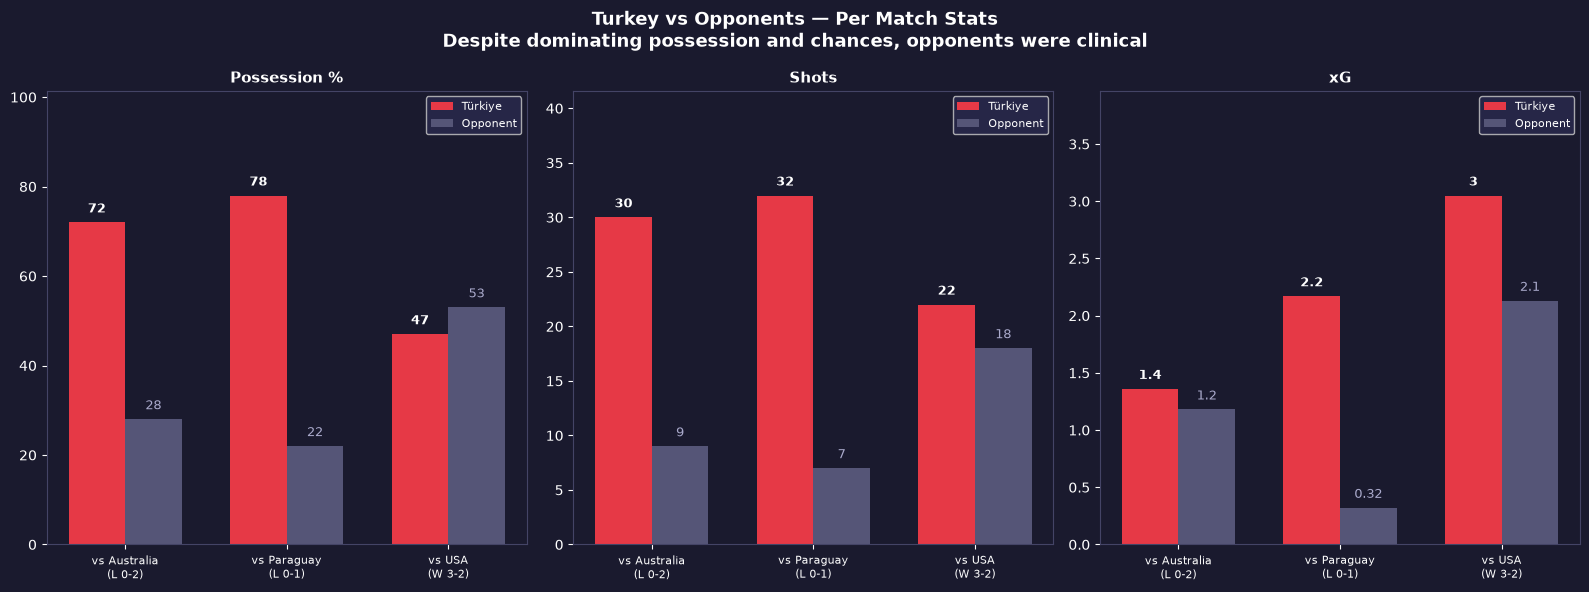

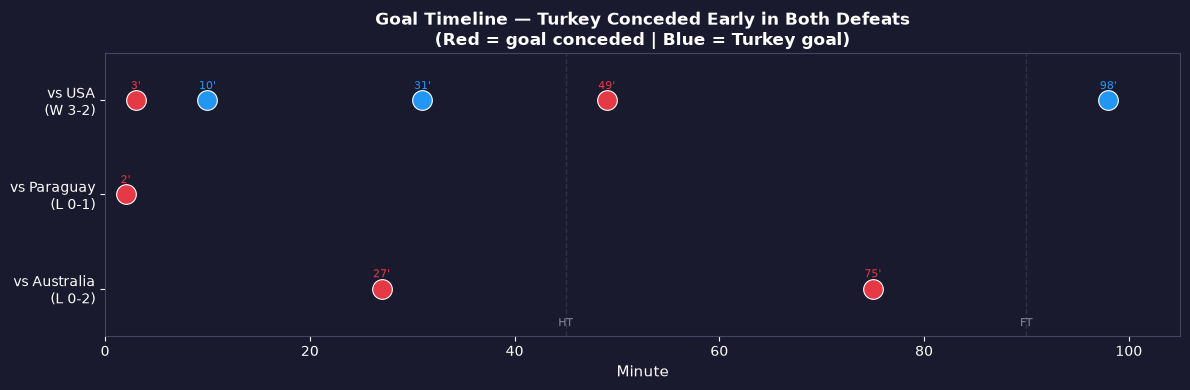

Key insight: Turkey conceded at 27', 2' in defeats — early goals forced chasing games.


In [52]:
# Per-match data from FotMob (Opta)
match_data = pd.DataFrame([
    ('vs Australia\n(L 0-2)', 72, 30, 1.36,  9, 1.18, 2),
    ('vs Paraguay\n(L 0-1)', 78, 32, 2.17,  7, 0.32, 1),
    ('vs USA\n(W 3-2)',       47, 22, 3.05, 18, 2.13, 2),
], columns=['match','tk_poss','tk_shots','tk_xg','opp_shots','opp_xg','opp_goals'])

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Turkey vs Opponents — Per Match Stats\n'
             'Despite dominating possession and chances, opponents were clinical',
             color=WHITE, fontsize=13, fontweight='bold')

comparisons = [
    ('Possession %',  'tk_poss',  lambda r: 100 - r['tk_poss']),
    ('Shots',         'tk_shots', lambda r: r['opp_shots']),
    ('xG',            'tk_xg',    lambda r: r['opp_xg']),
]

for ax, (label, tk_col, opp_fn) in zip(axes, comparisons):
    style(ax, fig)
    x       = np.arange(len(match_data))
    w       = 0.35
    tk_vals  = match_data[tk_col].values
    opp_vals = np.array([opp_fn(r) for _, r in match_data.iterrows()])
    b1 = ax.bar(x - w/2, tk_vals,  w, color=TR,     label='Türkiye', edgecolor='none')
    b2 = ax.bar(x + w/2, opp_vals, w, color=OTHERS, label='Opponent', edgecolor='none')
    ymax = max(tk_vals.max(), opp_vals.max())
    for bar, v in zip(b1, tk_vals):
        ax.text(bar.get_x()+bar.get_width()/2, v + ymax*0.02,
                f'{v:.2g}', ha='center', va='bottom', color=WHITE, fontsize=9, fontweight='bold')
    for bar, v in zip(b2, opp_vals):
        ax.text(bar.get_x()+bar.get_width()/2, v + ymax*0.02,
                f'{v:.2g}', ha='center', va='bottom', color='#aaaacc', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(match_data['match'], fontsize=8)
    ax.set_title(label, color=WHITE, fontsize=11, fontweight='bold')
    ax.set_ylim(0, ymax * 1.3)
    ax.legend(facecolor='#2a2a4e', labelcolor=WHITE, fontsize=8)

plt.tight_layout()
plt.savefig('per_match_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# Goal timing chart
fig, ax = plt.subplots(figsize=(12, 4))
style(ax, fig)

goal_events = [
    (27, 'vs Australia\n(L 0-2)', False),
    (75, 'vs Australia\n(L 0-2)', False),
    (2,  'vs Paraguay\n(L 0-1)', False),
    (10, 'vs USA\n(W 3-2)',      True),
    (31, 'vs USA\n(W 3-2)',      True),
    (3,  'vs USA\n(W 3-2)',      False),
    (49, 'vs USA\n(W 3-2)',      False),
    (98, 'vs USA\n(W 3-2)',      True),
]

match_y = {'vs Australia\n(L 0-2)': 1, 'vs Paraguay\n(L 0-1)': 2, 'vs USA\n(W 3-2)': 3}
for minute, match, is_turkey in goal_events:
    color = '#2196F3' if is_turkey else '#e63946'
    ax.scatter(minute, match_y[match], color=color, s=200, zorder=4,
               edgecolors='white', linewidths=0.8)
    ax.text(minute, match_y[match]+0.12, f"{minute}'",
            ha='center', fontsize=8, color=color)

ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['vs Australia\n(L 0-2)', 'vs Paraguay\n(L 0-1)', 'vs USA\n(W 3-2)'],
                   color=WHITE, fontsize=10)
ax.set_xlim(0, 105)
ax.set_xlabel('Minute', color=WHITE, fontsize=11)
ax.set_title("Goal Timeline — Turkey Conceded Early in Both Defeats\n"
             "(Red = goal conceded | Blue = Turkey goal)",
             color=WHITE, fontsize=12, fontweight='bold')
ax.axvline(45, color=WHITE, alpha=0.1, lw=1, linestyle='--')
ax.axvline(90, color=WHITE, alpha=0.1, lw=1, linestyle='--')
ax.text(45, 0.6, 'HT', color='#888899', ha='center', fontsize=8)
ax.text(90, 0.6, 'FT', color='#888899', ha='center', fontsize=8)
ax.set_ylim(0.5, 3.5)

plt.tight_layout()
plt.savefig('goal_timeline.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Key insight: Turkey conceded at 27', 2' in defeats — early goals forced chasing games.")

## Step 11: Comparison with Other Eliminated Teams

Data from xGscore.io — all 48 group-stage teams, including teams that advanced.
This comparison focuses on two dimensions:

- **xG created** — how many goals *should* they have scored based on chance quality?
- **xG delta** — how much did they over/underperform? (negative = scored fewer than expected)

Turkey's xG of **6.6** is the highest of any eliminated team — and their delta of **−3.6**
(scored 3.0 goals fewer than expected) is the **worst xG underperformance in the entire tournament**.

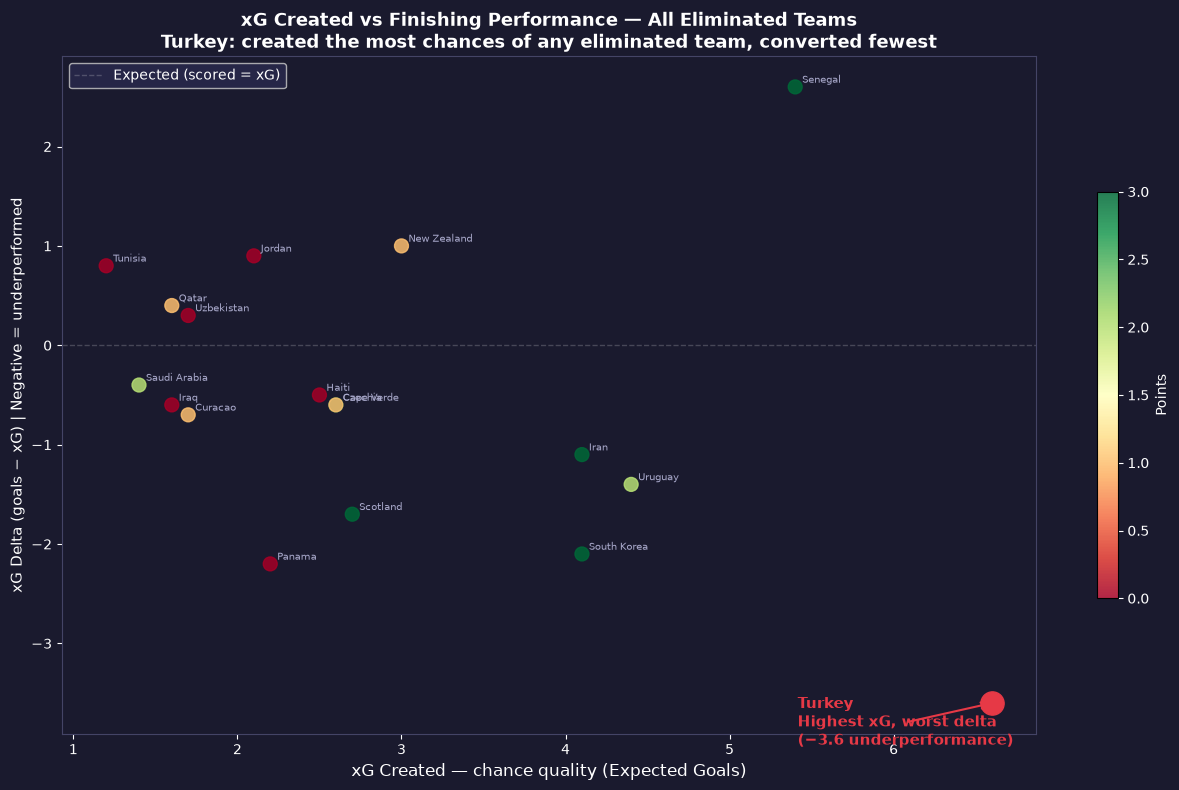

Turkey xG underperformance rank: #1 of 48 teams (worst in tournament)
xG: 6.6 | Goals: 3 | Delta: -3.6

Top 5 underperformers:
          team   xG  goals  xg_delta  points
0       Turkey  6.6      3      -3.6       3
1      Ecuador  5.1      2      -3.1       4
2       Panama  2.2      0      -2.2       0
3  South Korea  4.1      2      -2.1       3
4     Scotland  2.7      1      -1.7       3


In [53]:
# Full 48-team xG data from xGscore.io (group stage complete)
xg_all = pd.DataFrame([
    ('France',        6.1, 10, 2.7,  2,  9), ('Argentina',     5.4,  8, 1.7,  1,  9),
    ('Mexico',        3.8,  6, 1.7,  0,  9), ('Netherlands',   5.5, 10, 2.7,  4,  7),
    ('Brazil',        7.0,  7, 2.9,  1,  7), ('Spain',         5.5,  5, 0.7,  0,  7),
    ('Switzerland',   6.1,  7, 2.7,  3,  7), ('England',       6.1,  6, 1.7,  2,  7),
    ('Morocco',       5.9,  6, 2.9,  3,  7), ('Colombia',      4.6,  4, 2.5,  1,  7),
    ('Germany',       6.8, 10, 2.9,  4,  6), ('USA',           4.9,  8, 3.6,  4,  6),
    ('Ivory Coast',   4.0,  4, 3.5,  2,  6), ('Norway',        6.0,  8, 4.2,  7,  6),
    ('Croatia',       2.8,  5, 4.3,  5,  6), ('Portugal',      4.3,  6, 3.0,  1,  5),
    ('Japan',         3.9,  7, 2.0,  3,  5), ('Belgium',       6.8,  6, 2.1,  2,  5),
    ('Egypt',         4.0,  5, 4.5,  3,  5), ('Canada',        7.5,  8, 2.2,  3,  4),
    ('Congo DR',      3.4,  4, 2.2,  3,  4), ('Sweden',        3.5,  7, 4.1,  7,  4),
    ('Austria',       3.6,  6, 4.5,  6,  4), ('Australia',     2.3,  2, 3.2,  2,  4),
    ('Ecuador',       5.1,  2, 2.9,  2,  4), ('Ghana',         2.0,  2, 2.9,  2,  4),
    ('Bosnia',        2.1,  5, 4.2,  6,  4), ('South Africa',  2.7,  2, 3.5,  3,  4),
    ('Algeria',       4.1,  5, 3.4,  7,  4), ('Paraguay',      1.3,  2, 4.6,  4,  4),
    ('Senegal',       5.4,  8, 4.0,  6,  3), ('Iran',          4.1,  3, 4.2,  3,  3),
    ('Cape Verde',    2.6,  2, 4.9,  2,  3), ('South Korea',   4.1,  2, 2.7,  3,  3),
    ('Turkey',        6.6,  3, 3.7,  5,  3), ('Scotland',      2.7,  1, 6.0,  4,  3),
    ('Uruguay',       4.4,  3, 2.5,  4,  2), ('Saudi Arabia',  1.4,  1, 5.7,  5,  2),
    ('Czechia',       2.6,  2, 5.3,  6,  1), ('New Zealand',   3.0,  4, 7.1, 10,  1),
    ('Qatar',         1.6,  2, 8.4, 10,  1), ('Curacao',       1.7,  1, 8.3,  9,  1),
    ('Panama',        2.2,  0, 4.3,  4,  0), ('Jordan',        2.1,  3, 5.5,  8,  0),
    ('Haiti',         2.5,  2, 6.3,  8,  0), ('Uzbekistan',    1.7,  2, 6.3, 11,  0),
    ('Tunisia',       1.2,  2, 5.4, 12,  0), ('Iraq',          1.6,  1, 8.1, 12,  0),
], columns=['team','xG','goals','xGA','goals_conceded','points'])

xg_all['xg_delta'] = xg_all['goals'] - xg_all['xG']   # negative = underperformed

# Focus: teams that were eliminated (<=3 points)
eliminated = xg_all[xg_all['points'] <= 3].copy()

fig, ax = plt.subplots(figsize=(13, 8))
style(ax, fig)

others_e = eliminated[eliminated['team'] != 'Turkey']
tk_e     = eliminated[eliminated['team'] == 'Turkey'].iloc[0]

sc = ax.scatter(others_e['xG'], others_e['xg_delta'],
               c=others_e['points'], cmap='RdYlGn',
               vmin=0, vmax=3, s=100, alpha=0.85, zorder=2)

for _, r in others_e.iterrows():
    ax.annotate(r['team'], (r['xG'], r['xg_delta']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=7.5, color='#aaaacc')

ax.scatter(tk_e['xG'], tk_e['xg_delta'], color=TR, s=280, zorder=5)
ax.annotate('Turkey\nHighest xG, worst delta\n(−3.6 underperformance)',
            (tk_e['xG'], tk_e['xg_delta']),
            xytext=(-140, -30), textcoords='offset points',
            fontsize=11, color=TR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TR, lw=1.5))

ax.axhline(0, color=WHITE, alpha=0.2, lw=1, linestyle='--',
           label='Expected (scored = xG)')

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label('Points', color=WHITE)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=WHITE)
cbar.ax.yaxis.set_tick_params(color=WHITE)

ax.set_xlabel('xG Created — chance quality (Expected Goals)', fontsize=12)
ax.set_ylabel('xG Delta (goals − xG) | Negative = underperformed', fontsize=11)
ax.set_title('xG Created vs Finishing Performance — All Eliminated Teams\n'
             'Turkey: created the most chances of any eliminated team, converted fewest',
             fontsize=13, fontweight='bold')
ax.legend(facecolor='#2a2a4e', labelcolor=WHITE)

plt.tight_layout()
plt.savefig('eliminated_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# Print ranking
ranked_delta = xg_all.sort_values('xg_delta').reset_index(drop=True)
tk_rank = ranked_delta[ranked_delta['team']=='Turkey'].index[0] + 1
print(f"Turkey xG underperformance rank: #{tk_rank} of 48 teams (worst in tournament)")
print(f"xG: {tk_e['xG']} | Goals: {int(tk_e['goals'])} | Delta: {tk_e['xg_delta']:.1f}")
print()
print("Top 5 underperformers:")
print(ranked_delta[['team','xG','goals','xg_delta','points']].head())